In [25]:
# Imports
import matplotlib.pyplot as plt
from astropy import units as u
from astropy.io import fits
from astropy.wcs import WCS
from astropy.visualization.wcsaxes import WCSAxes
from astropy.coordinates import SkyCoord, FK5
from spectral_cube import SpectralCube
from velocity_tools import extract_streamline, gradient_descent, stream_lines_grad
from velocity_tools import stream_lines # won't use this directly, but needed to compare with stream_lines_grad
import os
import numpy as np
import jax
import jax.numpy as jnp
from jax import value_and_grad


import warnings
warnings.filterwarnings('ignore', message='.*PV2_1.*')
warnings.filterwarnings('ignore', message='.*PV2_2.*')
warnings.filterwarnings('ignore', message='.*TIMESYS.*')

# Settings
hltau_c= SkyCoord("4h31m38.43s", "+18d13m57.19s", frame='fk5')
hltau_ref = hltau_c.skyoffset_frame()
distance = 147 #parsecs
cubefile = 'test_data/HLTAU_HCOp32.fits'
file_TdV = 'test_data/HLTAU_HCOp32_TdV.fits'


### TODO: Extract streamer cube from original cube

Do this here

### Prepare the 1D streamer emission from the cube

In [26]:
# get the spectralcube object from the data using spectral-cube
hdu = fits.open(cubefile)[0]
cube = SpectralCube.read(hdu).with_spectral_unit(u.km/u.s, rest_value=hdu.header['RESTFRQ']*u.Hz)

# if the mom0 map isn't made yet, make it
if not os.path.exists(file_TdV):
    cube_mom0 = cube.moment0()
    hdu_mom0 = cube_mom0.hdu
    hdu_mom0.writeto(file_TdV)
print("Loaded cube with shape:", cube.shape)

# TODO: this streamer extraction should be replaced with clustering-based streamer extraction

# extract the subcube with the streamer (we got this from the tipsy tutorial, no need to plot)
## Limits for extracting subcube with streamer
vmin = 7    # Min. vel. of streamer
vmax = 10
xmin = -3   # Min R.A. offset (arcsec) to consider for streamer
xmax = -1
ymin = -3   # Min. Decl. offset (arcsec) to consider for streamer
ymax = 0.5
rms_thresh = 4  # sigma threshold for streamer

# extract the streamer subcube
info_header = cube.header  # header of the cube, contains required information
x_conv_fac = 1/60/60/info_header['CDELT1']
xmin_p = int((xmin*x_conv_fac)+info_header['CRPIX1'])
xmax_p = int((xmax*x_conv_fac)+info_header['CRPIX1'])
y_conv_fac = 1/60/60/info_header['CDELT2']
ymin_p = int((ymin*y_conv_fac)+info_header['CRPIX2'])
ymax_p = int((ymax*y_conv_fac)+info_header['CRPIX2'])
vunit = cube.spectral_axis.unit
## Note: a check can be added to see if requested limits are within the limits of the cube itself

streamer_cubev = cube.spectral_slab(vmin*vunit,vmax*vunit)    # Selecting velocities
streamer_cubevc = streamer_cubev[:,min(ymin_p,ymax_p):max(ymin_p,ymax_p)   
                    ,min(xmin_p,xmax_p):max(xmin_p,xmax_p)]   # Selecting pixels
#     print(min(ymin_p,ymax_p),max(ymin_p,ymax_p),min(xmin_p,xmax_p),max(xmin_p,xmax_p)) 
streamer_cube = streamer_cubevc.with_mask(streamer_cubevc > rms_thresh*streamer_cubevc.mad_std())  # Removing low flux values 


Loaded cube with shape: (500, 401, 401)


In [27]:

# Extract 1D streamline from the data cube
pc_coords, pc_means, pc_stds = extract_streamline.reduce_to_1D(streamer_cube, n_elements=10)

# Prepare data for gradient descent
ra_data = pc_means[0] # offsets in arcsec
dec_data = pc_means[1] # offsets in arcsec
v_data = pc_means[2]   # velocities in km/s (rel to vlsr)

ra_sigma = pc_stds[0]
dec_sigma = pc_stds[1]
v_sigma = pc_stds[2]


data = (ra_data, dec_data, v_data)
uncertainties = (ra_sigma, dec_sigma, v_sigma)

Starting reduction
Created coordinate arrays
Got point cloud with 14974 points
Partition boundaries for projected distance metric: [1.031 1.122 1.176 1.234 1.3   1.383 1.48  1.602 1.732 1.898 3.251]


Text(0.5, 1.0, 'Extracted 1D Streamer emission')

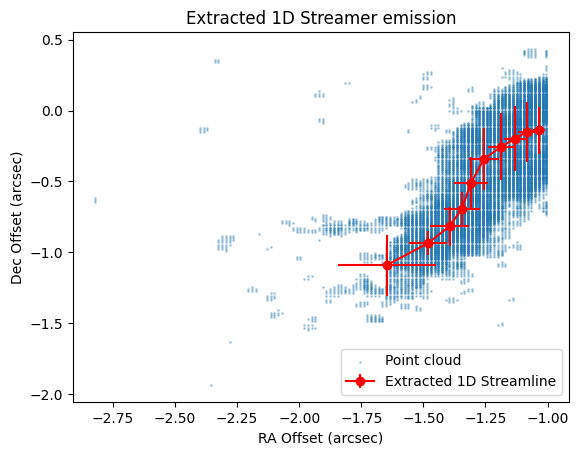

In [28]:
# plot it
import matplotlib.pyplot as plt
# plot the observed data points as a scatter
plt.scatter(pc_coords[0], pc_coords[1], s=1, alpha=0.3, label='Point cloud')
# plot the extracted 1D streamline with error bars
plt.errorbar(ra_data, dec_data, xerr=ra_sigma, yerr=dec_sigma, fmt='o-', label='Extracted 1D Streamline', color='red')
plt.xlabel('RA Offset (arcsec)')
plt.ylabel('Dec Offset (arcsec)')
plt.legend()
plt.title('Extracted 1D Streamer emission')

### Initial guess at parameters, and plot

The plot is so you can refine your initial parameters a bit. The comparison between stream_lines and stream_lines_grad is just a sanity check.

Running stream_lines...
rc=16.34705816821215 AU
ecc=0.9840119208088854
mu=0.02724509694702025
theta0=130.0 deg
orb_ang=0.0 rad
10.0 AU
tolerance  3.5903488968000007e-06
theta = [2.26892803 2.26869665 2.26845799 2.26820941 2.2679536  2.26768889
 2.26741317 2.26712693 2.26683146 2.26652273]
---------------------------------------------
Running stream_lines_grad...
rc=16.347009658813477 au
Plotting results...


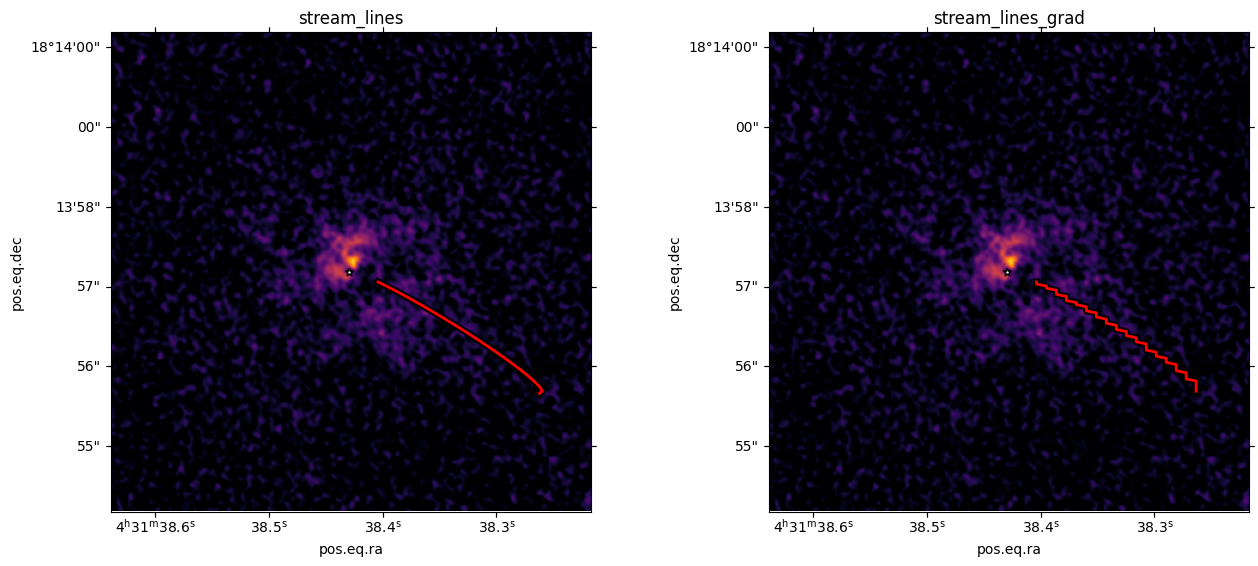

In [29]:
# Initial guesses at params
r0 = 600*u.au
theta0 = 130.*u.deg
phi0 = 150.*u.deg
omega0 = 4e-12/u.s
v_r0 = 0*u.km/u.s
# params we set
Mstar = 3.2*u.Msun
inc = -43*u.deg
PA_ang = 130*u.deg
v_lsr = 7.05*u.km/u.s


# Run the forward model with initial params - using stream_lines
# x = RA offset (au), y = velocity (km/s), z = Dec offset (au)
print("Running stream_lines...")
(x1, y1, z1), (vx1, vy1, vz1) = stream_lines.xyz_stream(
                mass=Mstar, r0=r0, theta0=theta0, phi0=phi0,
                omega=omega0, v_r0=v_r0, inc=inc, pa=PA_ang,
                rmin=0.5e2*u.au, deltar=10*u.au) #<- decrease deltar for more accurate streamer calculation
dra_stream1 = -x1.value / distance * u.arcsec 
ddec_stream1 = z1.value / distance * u.arcsec
fil1 = SkyCoord(dra_stream1, ddec_stream1, frame=hltau_ref).transform_to(FK5)

print("---------------------------------------------")

# Run the forward model with initial params - using stream_lines_grad
# convert angles to radians, and strip units from all quantities
r0 = r0.to(u.au).value
theta0 = theta0.to(u.rad).value
phi0 = phi0.to(u.rad).value
omega0 = omega0.to(1/u.s).value
v_r0 = v_r0.to(u.km/u.s).value
inc = inc.to(u.rad).value
PA_ang = PA_ang.to(u.rad).value
Mstar = Mstar.to(u.Msun).value
v_lsr = v_lsr.to(u.km/u.s).value
# x = RA offset (au), y = velocity (km/s), z = Dec offset (au)
print("Running stream_lines_grad...")
(x2, y2, z2), (vx2, vy2, vz2) = stream_lines_grad.xyz_stream(
                mass=Mstar, r0=r0, theta0=theta0, phi0=phi0,
                omega=omega0, v_r0=v_r0, inc=inc, pa=PA_ang,
                rmin=50, deltar=10) #<- decrease deltar for more accurate streamer calculation
dra_stream2 = -x2._value / distance * u.arcsec # note the _value to get raw number for stream_lines_grad
ddec_stream2 = z2._value / distance * u.arcsec
fil2 = SkyCoord(dra_stream2, ddec_stream2, frame=hltau_ref).transform_to(FK5)

print("Plotting results...")
# Load the moment 0 data
hdu = fits.open(file_TdV)[0]
wcs_TdV = WCS(hdu.header)

# Create figure with two subplots side by side
plt.close('all')
fig = plt.figure(figsize=(14, 6))

# Left subplot - stream_lines
ax1 = WCSAxes(fig, [0.05, 0.1, 0.4, 0.8], wcs=wcs_TdV.celestial)
fig.add_axes(ax1)
im1 = ax1.imshow(hdu.data, cmap='inferno', vmin=0, vmax=160.e-3)
ax1.scatter(hltau_c.ra, hltau_c.dec, marker='*', transform=ax1.get_transform('world'),
    facecolor='white', edgecolor='black')
ax1.plot(fil1.ra, fil1.dec, color='black', transform=ax1.get_transform('world'), linewidth=5)
ax1.plot(fil1.ra, fil1.dec, color='red', transform=ax1.get_transform('world'), linewidth=2)
ax1.set_title('stream_lines')

# Right subplot - stream_lines_grad
ax2 = WCSAxes(fig, [0.52, 0.1, 0.4, 0.8], wcs=wcs_TdV.celestial)
fig.add_axes(ax2)
im2 = ax2.imshow(hdu.data, cmap='inferno', vmin=0, vmax=160.e-3)
ax2.scatter(hltau_c.ra, hltau_c.dec, marker='*', transform=ax2.get_transform('world'),
    facecolor='white', edgecolor='black')
ax2.plot(fil2.ra, fil2.dec, color='black', transform=ax2.get_transform('world'), linewidth=5)
ax2.plot(fil2.ra, fil2.dec, color='red', transform=ax2.get_transform('world'), linewidth=2)
ax2.set_title('stream_lines_grad')

plt.show()


### Forward model and calculating loss

First set your input params in the format required

In [30]:
# Parameters to optimize
initial_opt_params = {
    'r0': 600.0,  # au
    'theta0': 130.0,  # degrees
    'phi0': 150.0,  # degrees
    'omega': 4e-12,  # 1/s
    'v_r0': 0.0,  # km/s
}

# Fixed parameters (not optimized)
fixed_params = {
    'mass': 2.1,  # Msun
    'inc': -43.0,  # degrees
    'pa': 130.0,  # degrees
    'rmin': 50.0,  # au
    'deltar': 10.0,  # au
    'v_lsr': 7.14  # km/s (systemic velocity)
}

# Convert angles from degrees to radians
initial_opt_params['theta0'] = np.radians(initial_opt_params['theta0'])
initial_opt_params['phi0'] = np.radians(initial_opt_params['phi0'])
fixed_params['inc'] = np.radians(fixed_params['inc'])
fixed_params['pa'] = np.radians(fixed_params['pa'])

Doing chi2 loss more manually, just so we can check the model point choosing is working properly (delete this later)

rc=24.90972900390625 au
Chi-squared RA: 1405.63, Dec: 100.99, Velocity: 47414.44, Total: 48921.05


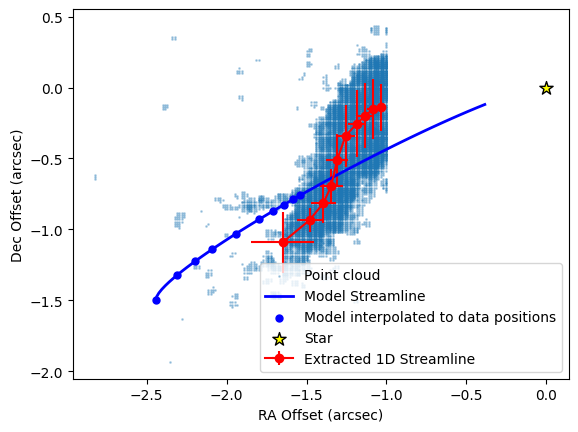

In [31]:
# forward model
ra_model, dec_model, v_model = gradient_descent.forward_model(initial_opt_params, fixed_params, distance)
# remove NaN values (due to rmin) from model
not_nan = ~jnp.isnan(ra_model) & ~jnp.isnan(dec_model) & ~jnp.isnan(v_model)
ra_model = ra_model[not_nan]
dec_model = dec_model[not_nan]
v_model = v_model[not_nan]

# Match model to data using arc-length parameterisation
ra_model_interp, dec_model_interp, v_model_interp, valid = gradient_descent.match_model_to_data_curve(
    ra_model, dec_model, v_model, ra_data, dec_data)



# mask for valid (only for arrays that haven't already been masked in matching)
v_data = v_data[valid]
ra_sigma = ra_sigma[valid]
dec_sigma = dec_sigma[valid]
v_sigma = v_sigma[valid]

# Compute chi-squared components
chi2_ra = jnp.sum(((ra_data - ra_model_interp) / ra_sigma)**2)
chi2_dec = jnp.sum(((dec_data - dec_model_interp) / dec_sigma)**2)
chi2_v = jnp.sum(((v_data - v_model_interp) / v_sigma)**2)
# Total chi-squared
chi2_total = chi2_ra + chi2_dec + chi2_v
print(f"Chi-squared RA: {chi2_ra:.2f}, Dec: {chi2_dec:.2f}, Velocity: {chi2_v:.2f}, Total: {chi2_total:.2f}")


# plot it
import matplotlib.pyplot as plt
# plot the observed data points as a scatter
plt.scatter(pc_coords[0], pc_coords[1], s=1, alpha=0.3, label='Point cloud')
# plot the extracted 1D data streamline with error bars
plt.errorbar(ra_data, dec_data, xerr=ra_sigma, yerr=dec_sigma, fmt='o-', label='Extracted 1D Streamline', color='red')
# plot the model streamline
plt.plot(ra_model, dec_model, 'b-', linewidth=2, label='Model Streamline')
# plot the model streamline interpolated to data positions
plt.scatter(ra_model_interp, dec_model_interp, s=25, label='Model interpolated to data positions', color='blue', zorder=5)
# plot the star
plt.scatter(0, 0, marker='*', s=100, color='yellow', edgecolor='black', label='Star', zorder=10)
plt.xlabel('RA Offset (arcsec)')
plt.ylabel('Dec Offset (arcsec)')
plt.legend()


In [32]:
# All the above could be done just by calling chi2_loss
initial_loss = gradient_descent.chi2_loss(initial_opt_params, fixed_params, data, uncertainties, distance)
print(f"Initial chi-squared loss: {initial_loss:.2f}")

rc=24.90972900390625 au
Initial chi-squared loss: 48921.05


### Directly testing gradients

In [33]:


def test_gradients(params, data):
    try:
        # do a forward pass and compute loss
        loss_val = gradient_descent.chi2_loss(initial_opt_params, fixed_params, data, uncertainties, distance)
        print(f"Loss value: {loss_val}, type: {type(loss_val)}, shape: {getattr(loss_val, 'shape', 'no shape')}")
        
        grad_fn = jax.jacfwd(lambda p: gradient_descent.chi2_loss(p, fixed_params, data, uncertainties, distance))
        grads = grad_fn(params)
        print(f"Gradients computed successfully: {grads}")
        return grads
    except Exception as e:
        print(f"Error computing gradients: {e}")
        import traceback
        traceback.print_exc()
        return None
    
grads = test_gradients(initial_opt_params, data)







rc=24.90972900390625 au
Loss value: 48921.05078125, type: <class 'jaxlib._jax.ArrayImpl'>, shape: ()
rc=24.90972900390625 au
Gradients computed successfully: {'omega': Array(3.1709774e+14, dtype=float32), 'phi0': Array(3322.3188, dtype=float32), 'r0': Array(16.756012, dtype=float32), 'theta0': Array(2098.4204, dtype=float32), 'v_r0': Array(0., dtype=float32)}


### Testing one gradient descent step (the first step)

In [34]:
opt_params = initial_opt_params.copy()

# Initialize Adam moments (only for optimizable parameters)
m = {key: 0.0 for key in opt_params.keys()}
v = {key: 0.0 for key in opt_params.keys()}
# let's set learning rate and Adam parameters (I don't really know what these are)
learning_rate = 1e-2
beta1 = 0.9
beta2 = 0.999

# Create gradient function (only w.r.t. opt_params)
loss_and_grad_fn = value_and_grad(gradient_descent.chi2_loss, argnums=0)

# track loss history
loss_history = []
best_loss = float('inf')
best_opt_params = opt_params.copy()
patience_counter = 0

# let's just do one epoch to test
# Get loss and gradients
loss_value, grads = loss_and_grad_fn(opt_params, fixed_params, data, uncertainties, distance)
print(f"Initial loss: {loss_value:.2f}")
# perform one Adam update to params
opt_params, m, v = gradient_descent.adam_step(
    opt_params, grads, m, v, t=1, learning_rate=learning_rate, beta1=beta1, beta2=beta2
)

# track loss
loss_history.append(loss_value)

# print new params
print("Updated parameters after one Adam step:")
for key in opt_params.keys():
    print(f"  {key}: {opt_params[key]:.6f}")

rc=24.90972900390625 au
Initial loss: 48921.05
Updated parameters after one Adam step:
  r0: 599.989990
  theta0: 2.258928
  phi0: 2.607994
  omega: -0.010000
  v_r0: 0.000000


### Testing fit_streamline

### Using per-parameter learning rates

Since parameters are on very different scales (e.g., omega~1e-12, r0~600), we need different learning rates for each parameter to avoid instability.

Starting optimization with 10 epochs...
Optimizing parameters: ['r0', 'theta0', 'phi0', 'omega', 'v_r0']
Fixed parameters: ['mass', 'inc', 'pa', 'rmin', 'deltar', 'v_lsr']
Initial optimizable values: {'r0': 600.0, 'theta0': np.float64(2.2689280275926285), 'phi0': np.float64(2.6179938779914944), 'omega': 4e-12, 'v_r0': 0.0}

 Starting Epoch 1 -------------------------
rc=24.90972900390625 au
Epoch 1/10, Loss: 48921.050781, Best Loss: 48921.050781
  Current optimizable params: {'r0': Array(550., dtype=float32), 'theta0': Array(2.1689281, dtype=float32), 'phi0': Array(2.517994, dtype=float32), 'omega': Array(3.999e-12, dtype=float32), 'v_r0': Array(0., dtype=float32, weak_type=True)}

 Starting Epoch 2 -------------------------
rc=17.579137802124023 au
Epoch 2/10, Loss: 48500.609375, Best Loss: 48500.609375
  Current optimizable params: {'r0': Array(504.6571, dtype=float32), 'theta0': Array(2.073523, dtype=float32), 'phi0': Array(2.5501382, dtype=float32), 'omega': Array(3.9981187e-12, dt

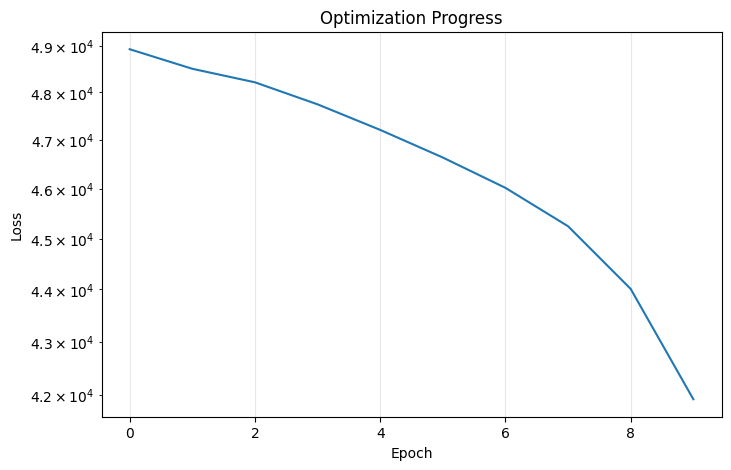

In [35]:
opt_params = initial_opt_params.copy()

# Define per-parameter learning rates based on parameter scales
# This is optional in the code but highly recommended due to differing parameter scales
learning_rates = {
    'r0': 50,          # order 10^3 au - use larger learning rate
    'theta0': 0.1,     # 0-2 radians - moderate learning rate
    'phi0': 0.1,       # 0-2 radians - moderate learning rate
    'omega': 1e-15,      # order 10^-13 - use much smaller learning rate
    'v_r0': 0.1        # ~0-10 km/s - moderate learning rate
}

# Define physically reasonable bounds (this is optional in the code)
param_bounds = {
    'r0': (100.0, 20000.0),         # radius between 100-20000 au
    'theta0': (0.0, np.pi),         # polar angle 0-pi
    'phi0': (0.0, 2*np.pi),         # azimuthal angle 0-2pi
    'omega': (1e-16, 1e-9),         # angular velocity reasonable range.
    'v_r0': (-5.0, 5.0)             # radial velocity -5 to 5 km/s
}
#TODO: might need to scale omega for better precision as the numbers are really small

best_opt_params, loss_history = gradient_descent.fit_streamline(
    opt_params,
    fixed_params,
    data, 
    uncertainties,
    distance,
    learning_rate=0.001,
    learning_rate_dict=learning_rates,
    param_bounds=param_bounds,
    n_epochs=10,
    info_every=1,
    early_stopping_patience=5
)

print("Done!")
print("---------------------------------------------")
print("Best-fit parameters:")
for key in best_opt_params.keys():
    print(f"  {key}: {best_opt_params[key]:.6f}")
    
# Plot loss history
plt.figure(figsize=(8, 5))
plt.plot(loss_history)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Optimization Progress')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.show()


rc=0.5364317297935486 au


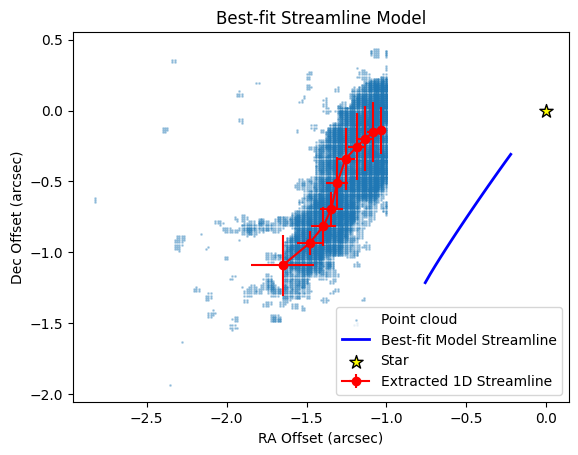

In [37]:
# Final model with best-fit parameters
ra_best, dec_best, v_best = gradient_descent.forward_model(best_opt_params, fixed_params, distance)
# remove NaN values (due to rmin) from model
not_nan = ~jnp.isnan(ra_best) & ~jnp.isnan(dec_best) & ~jnp.isnan(v_best)
ra_best = ra_best[not_nan]
dec_best = dec_best[not_nan]
v_best = v_best[not_nan]
# plot it on top of the data
plt.scatter(pc_coords[0], pc_coords[1], s=1, alpha=0.3, label='Point cloud')
# plot the extracted 1D data streamline with error bars
plt.errorbar(ra_data, dec_data, xerr=ra_sigma, yerr=dec_sigma, fmt='o-', label='Extracted 1D Streamline', color='red')
# plot the best-fit model streamline
plt.plot(ra_best, dec_best, color='blue', linewidth=2, label='Best-fit Model Streamline')
# plot the star
plt.scatter(0, 0, marker='*', s=100, color='yellow', edgecolor='black', label='Star', zorder=10)
plt.xlabel('RA Offset (arcsec)')
plt.ylabel('Dec Offset (arcsec)')
plt.legend()
plt.title('Best-fit Streamline Model')
plt.show()